# Example end-to-end generator

Builds the toy v1.0 example dataset: 4 regions × 3 segments × 26 years (2025–2050), plus three growth-parameter variants per segment.

This notebook is intentionally shrunk-down — a working reference for someone forking `energy-toolkit-demand` who needs to see the full pipeline wired up at the smallest possible scale.

**What it produces**

- `data/base/example/{segment}/data.parquet` — base scenario, one file per segment
- `data/parameters/{segment}_growth/{index}/{segment}/data.parquet` — growth parameter variants (`low`/`mid`/`high` → indices 1/2/3)
- `generator/input/example/curves/{segment}_growth.parquet` — the per-segment multiplier curves referenced by `config.yaml` (reference only; the API doesn't read them)
- `api/data/geographies.geojson` — copy of `regions.geojson` so `/geographies?format=geojson` resolves

**Expected runtime:** ~20 seconds on a laptop.


In [1]:
from __future__ import annotations

import json
import shutil
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

# Assume the notebook is run from the repo root; fall back to walking up if
# launched from the notebooks directory itself.
REPO = Path.cwd()
if not (REPO / 'config.yaml').exists():
    REPO = REPO.parents[1]
assert (REPO / 'config.yaml').exists(), f'config.yaml not found relative to {REPO}'

INPUT = REPO / 'generator' / 'input' / 'example'
DATA = REPO / 'data'
API_DATA = REPO / 'api' / 'data'

sys.path.insert(0, str(REPO))
from generator.library.curves import generate_linear, generate_s_curve


## 1. Load inputs

Config, scenario spec, toy geography, and the three profile CSVs.

In [2]:
config = yaml.safe_load((REPO / 'config.yaml').read_text())
scenario = yaml.safe_load((INPUT / 'scenario_example.yaml').read_text())
geojson = json.loads((INPUT / 'regions.geojson').read_text())
profiles = {
    seg: pd.read_csv(INPUT / f'profile_{seg}.csv')
    for seg in ('housing', 'industry', 'services')
}

print('scenario_id      :', scenario['scenario_id'])
print('regions          :', [f['properties']['geo_id'] for f in geojson['features']])
print('segments         :', list(profiles.keys()))
print('profile row count:', {k: len(v) for k, v in profiles.items()})


scenario_id      : example
regions          : ['A', 'B', 'C', 'D']
segments         : ['housing', 'industry', 'services']
profile row count: {'housing': 8760, 'industry': 8760, 'services': 8760}


## 2. Base growth curves

NEXT_STEPS locks in *two segments using `generate_linear` and one using `generate_s_curve`*. Housing and industry ramp linearly; services follows an s-curve with a 5-year transition window.

The returned DataFrames are indexed at hourly resolution over the full 2025–2050 span so they line up one-to-one with the hourly profile repeat below.


In [3]:
def build_base_curve(segment: str, spec: dict) -> pd.Series:
    if spec['curve'] == 'linear':
        df = generate_linear(f'{segment}_base', 2025, 2050, spec['y0'], spec['y1'])
    elif spec['curve'] == 's_curve':
        df = generate_s_curve(
            f'{segment}_base', 2025, 2050, spec['y0'], spec['y1'],
            steepness=spec.get('steepness', 10.0),
        )
    else:
        raise ValueError(spec['curve'])
    return df.set_index('timestamp')['value']


base_curves = {
    seg: build_base_curve(seg, scenario['base_growth'][seg])
    for seg in ('housing', 'industry', 'services')
}
for seg, curve in base_curves.items():
    print(f'{seg:8} {scenario["base_growth"][seg]["curve"]:7} '
          f'2025={curve.iloc[0]:.3f} 2050={curve.iloc[-1]:.3f}')


housing  linear  2025=1.000 2050=1.300
industry linear  2025=1.000 2050=1.100
services s_curve 2025=1.000 2050=1.500


## 3. Assemble the base dataset

For each region × segment, multiply `base_total` × `hourly profile shape` × `base growth curve`.

**Units.** `config.units.energy.prefix` is `G`, so the values stored in the parquet files are in **GWh** — the explorer's `formatNumber` treats the stored number as already being in `prefix × unit` (here `GWh`) and rescales for display.

Leap days re-use the Feb 28 slice of the 8760-hour profile (cheap approximation, avoids an extra 24 rows per leap year).


In [4]:
def hour_of_year(ts: pd.DatetimeIndex) -> np.ndarray:
    doy = ts.dayofyear.to_numpy()
    h = ts.hour.to_numpy()
    return np.clip((doy - 1) * 24 + h, 0, 8759)


start = pd.Timestamp('2025-01-01 00:00:00')
end = pd.Timestamp('2050-12-31 23:00:00')
ts = pd.date_range(start, end, freq='1h')
hoy = hour_of_year(ts)
years = ts.year.to_numpy()

base_by_segment: dict[str, pd.DataFrame] = {}
for segment in ('housing', 'industry', 'services'):
    profile_h = profiles[segment]['value'].to_numpy()[hoy]
    growth_h = base_curves[segment].reindex(ts).to_numpy()

    rows = []
    for geo_id, seg_totals in scenario['base_totals'].items():
        total_gwh = seg_totals[segment]
        values = total_gwh * profile_h * growth_h
        rows.append(pd.DataFrame({
            'scenario_id': 'example',
            'geography': geo_id,
            'segment': segment,
            'timestamp': ts,
            'timestamp_year': years,
            'value': values.astype('float32'),
        }))
    base_by_segment[segment] = pd.concat(rows, ignore_index=True)

{seg: df.shape for seg, df in base_by_segment.items()}


{'housing': (911616, 6), 'industry': (911616, 6), 'services': (911616, 6)}

## 4. Write base parquets

Layout: `data/base/{scenario_id}/{segment}/data.parquet` — matches what `api/query-builder.js` expects.

In [5]:
base_dir = DATA / 'base' / 'example'
for segment, df in base_by_segment.items():
    target = base_dir / segment / 'data.parquet'
    target.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(target, index=False, compression='snappy')
    print(f'wrote {target.relative_to(REPO)}  rows={len(df):,}')


wrote data/base/example/housing/data.parquet  rows=911,616


wrote data/base/example/industry/data.parquet  rows=911,616


wrote data/base/example/services/data.parquet  rows=911,616


## 5. Growth parameter variants

Each segment gets its own parameter definition (`housing_growth`, `industry_growth`, `services_growth`) because `query-builder.js` hard-codes a per-segment lookup. Each parameter has three non-baseline indices (1=low, 2=mid, 3=high) whose multiplier curves come from `scenario_example.yaml`.

Per parameter index we multiply the base timeseries by the linear multiplier curve and write to `data/parameters/{paramName}/{index}/{segment}/data.parquet`.


In [6]:
variants = scenario['growth_parameter']['indices']
params_dir = DATA / 'parameters'
for segment, base_df in base_by_segment.items():
    param_name = f'{segment}_growth'
    for v in variants:
        mult = generate_linear(
            f'{segment}_growth_{v["id"]}', 2025, 2050, v['y0'], v['y1']
        ).set_index('timestamp')['value'].reindex(pd.DatetimeIndex(base_df['timestamp'])).to_numpy()
        df = base_df.copy()
        df['value'] = (df['value'].to_numpy() * mult).astype('float32')
        target = params_dir / param_name / str(v['index']) / segment / 'data.parquet'
        target.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(target, index=False, compression='snappy')
        print(f'wrote {target.relative_to(REPO)}  id={v["id"]}')


wrote data/parameters/housing_growth/1/housing/data.parquet  id=low


wrote data/parameters/housing_growth/2/housing/data.parquet  id=mid


wrote data/parameters/housing_growth/3/housing/data.parquet  id=high


wrote data/parameters/industry_growth/1/industry/data.parquet  id=low


wrote data/parameters/industry_growth/2/industry/data.parquet  id=mid


wrote data/parameters/industry_growth/3/industry/data.parquet  id=high


wrote data/parameters/services_growth/1/services/data.parquet  id=low


wrote data/parameters/services_growth/2/services/data.parquet  id=mid


wrote data/parameters/services_growth/3/services/data.parquet  id=high


## 6. Curves parquet (reference only)

`config.yaml`'s `parameters.definitions.*.values[].curve.file` points at `generator/input/example/curves/{segment}_growth.parquet`. The API does not read these files — it consumes the pre-multiplied parquets under `data/parameters/` directly — but emitting them keeps the config references resolvable for tooling that inspects them (and matches the behovskartan reference layout).


In [7]:
curves_dir = INPUT / 'curves'
curves_dir.mkdir(parents=True, exist_ok=True)
for segment in ('housing', 'industry', 'services'):
    frames = []
    for v in variants:
        df = generate_linear(
            f'{segment}_growth_{v["id"]}', 2025, 2050, v['y0'], v['y1']
        )
        df['curve_id'] = v['id']
        df['index'] = v['index']
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    target = curves_dir / f'{segment}_growth.parquet'
    out.to_parquet(target, index=False)
    print(f'wrote {target.relative_to(REPO)}  rows={len(out):,}')


wrote generator/input/example/curves/housing_growth.parquet  rows=683,712


wrote generator/input/example/curves/industry_growth.parquet  rows=683,712


wrote generator/input/example/curves/services_growth.parquet  rows=683,712


## 7. Copy geojson to `api/data/`

So `api/generate-api.js`'s `generateGeographies` step picks it up alongside `config.yaml`.

In [8]:
API_DATA.mkdir(parents=True, exist_ok=True)
shutil.copyfile(INPUT / 'regions.geojson', API_DATA / 'geographies.geojson')
print('copied regions.geojson → api/data/geographies.geojson')


copied regions.geojson → api/data/geographies.geojson


## 8. Verify with DuckDB

Reads the parquets back via DuckDB (the same engine the API uses) and prints a summary + a sparkline of the national total over 2025–2050. Sanity check: 2025 totals should match `base_totals` in `scenario_example.yaml`; 2050 totals should reflect the baked-in growth (housing ×1.3, industry ×1.1, services ×1.5 via s-curve).


geography  segment  year        gwh
        A  housing  2025 100.577398
        A  housing  2050 129.424408
        A industry  2025  50.095821
        A industry  2050  54.903656
        A services  2025  70.000012
        A services  2050 104.999989
        B  housing  2025 150.866097
        B  housing  2050 194.136611
        B industry  2025  80.153313
        B industry  2050  87.845849
        B services  2025  60.000010
        B services  2050  89.999991
        C  housing  2025  80.461918
        C  housing  2050 103.539526
        C industry  2025 120.229969
        C industry  2050 131.768773
        C services  2025  90.000015
        C services  2050 134.999986
        D  housing  2025  60.346439
        D  housing  2050  77.654645
        D industry  2025 200.383282
        D industry  2050 219.614622
        D services  2025  40.000007
        D services  2050  59.999994


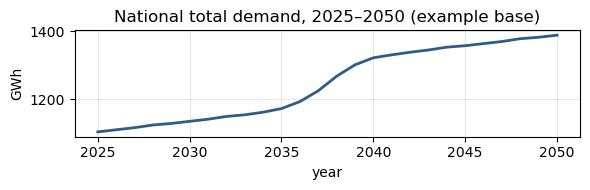

In [9]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect()
pattern = str(DATA / 'base' / 'example' / '*' / 'data.parquet')
summary = con.execute(f'''
    SELECT geography,
           segment,
           timestamp_year AS year,
           SUM(value) AS gwh
    FROM read_parquet('{pattern}')
    WHERE timestamp_year IN (2025, 2050)
    GROUP BY geography, segment, timestamp_year
    ORDER BY geography, segment, year
''').fetchdf()
print(summary.to_string(index=False))

national = con.execute(f'''
    SELECT timestamp_year AS year, SUM(value) AS gwh
    FROM read_parquet('{pattern}')
    GROUP BY year
    ORDER BY year
''').fetchdf()

fig, ax = plt.subplots(figsize=(6, 2))
ax.plot(national['year'], national['gwh'], color='#2E5C8A', linewidth=2)
ax.set_title('National total demand, 2025–2050 (example base)')
ax.set_xlabel('year'); ax.set_ylabel('GWh')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

**Next step:** run `node api/generate-api.js --defaults` from the repo root, then `cd api && npm start` and `cd explorer && npm run dev`. Open `http://localhost:5173/` (or whichever port vite reports) and the map should render four coloured regions.
